<a href="https://colab.research.google.com/github/Ansh-One8/Machine-Learning-models-and-algos/blob/main/spamhamprojectusingBOW.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

In [ ]:
import numpy as np


In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/sms-spam-collection-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'sms-spam-collection-dataset' dataset.
Path to dataset files: /kaggle/input/sms-spam-collection-dataset


In [ ]:
messages = pd.read_csv(f"{path}/spam.csv", encoding="latin-1")
messages.head()

,v1,v2,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,ham,"Go until jurong point, crazy.. Available only ...",NaN,NaN,NaN
1,ham,Ok lar... Joking wif u oni...,NaN,NaN,NaN
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...,NaN,NaN,NaN
3,ham,U dun say so early hor... U c already then say...,NaN,NaN,NaN
4,ham,"Nah I don't think he goes to usf, he lives aro...",NaN,NaN,NaN


In [ ]:
messages = messages[['v1' , 'v2']]
messages = messages.rename(columns =  {'v1' : 'label1' , 'v2': 'message'})

In [ ]:
messages

,label1,message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
...,...,...
5567,spam,This is the 2nd time we have tried 2 contact u...
5568,ham,Will Ì_ b going to esplanade fr home?
5569,ham,"Pity, * was in mood for that. So...any other s..."
5570,ham,The guy did some bitching but I acted like i'd...


In [ ]:
import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer


In [ ]:
lemmatizer = WordNetLemmatizer()

In [ ]:
import re
messages.reset_index(drop=True, inplace=True)

In [ ]:
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

In [ ]:

corpus = []
for i in range(0, len(messages)):
  review = re.sub('[^a-zA-Z]' , ' ' , messages['message'][i] )
  review = review.lower()
  review = review.split()
  review = [lemmatizer.lemmatize(word) for word in review if not word in set(stopwords.words('english'))]
  review = ' '.join(review)
  corpus.append(review)

# but this process can be done easily by using gensim.utils.simple_preprocess()
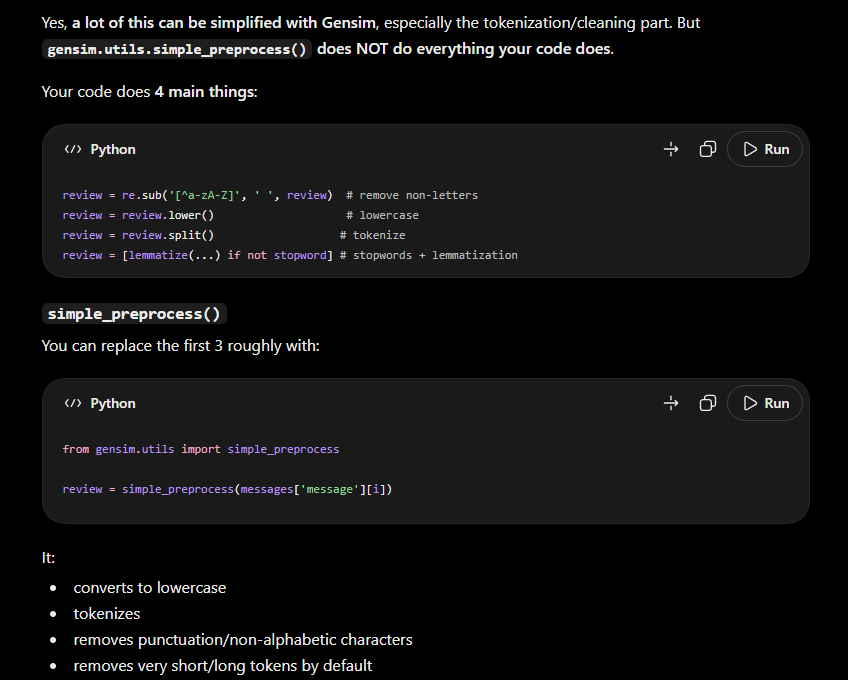





# still to do convert words into right lemma you have to do lemmatization


In [ ]:
## or you can use this via gensim
from gensim.utils import simple_preprocess

stop_words = set(stopwords.words('english'))

corpus = []

for message in messages['message']:
    review = simple_preprocess(message)

    review = [
        lemmatizer.lemmatize(word)
        for word in review
        if word not in stop_words
    ]

    corpus.append(' '.join(review))

In [ ]:
corpus

['go jurong point crazy available bugis n great world la e buffet cine got amore wat',
 'ok lar joking wif u oni',
 'free entry wkly comp win fa cup final tkts st may text fa receive entry question std txt rate c apply',
 'u dun say early hor u c already say',
 'nah think go usf life around though',
 'freemsg hey darling week word back like fun still tb ok xxx std chgs send rcv',
 'even brother like speak treat like aid patent',
 'per request melle melle oru minnaminunginte nurungu vettam set callertune caller press copy friend callertune',
 'winner valued network customer selected receivea prize reward claim call claim code kl valid hour',
 'mobile month u r entitled update latest colour mobile camera free call mobile update co free',
 'gonna home soon want talk stuff anymore tonight k cried enough today',
 'six chance win cash pound txt csh send cost p day day tsandcs apply reply hl info',
 'urgent week free membership prize jackpot txt word claim c www dbuk net lccltd pobox ldnw rw'

# Creating word2vec using bow


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer    # ab agr tfidf use krna hota toh tfidf vectorizer use krhe hote
cv = CountVectorizer(max_features=100)
X = cv.fit_transform(corpus).toarray()

In [ ]:
import numpy as np
np.set_printoptions( edgeitems= 30 , linewidth=100000 , formatter=dict(float=lambda x: "%.3g" % x))

#


In [ ]:
y  = pd.get_dummies(messages['label1'])
y = y.iloc[:,0].values.astype(int)
y

array([1, 1, 0, 1, 1, 0, 1, 1, 0, 0, 1, 0, 0, 1, 1, 0, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, ..., 1, 1, 1, 1, 1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1])

In [ ]:
# train test split
from sklearn.model_selection import train_test_split
X_train , X_test  ,Y_train , Y_test = train_test_split(X , y , test_size=0.2 , random_state=0)
#

In [ ]:
from sklearn.naive_bayes import MultinomialNB
# TRAINing on the multinomial naive bais as this perform better in sparse matrix
spam_detect_model = MultinomialNB().fit(X_train , Y_train )


In [ ]:
# NOW WE HAVE TO PREDICT THE DATA
y_pred= spam_detect_model.predict(X_test)

In [ ]:
from sklearn.metrics import classification_report , accuracy_score
accuracy_score(Y_test , y_pred)


0.95695067264574

In [ ]:
classification_report(Y_test , y_pred)

'              precision    recall  f1-score   support\n\n           0       0.89      0.81      0.85       166\n           1       0.97      0.98      0.97       949\n\n    accuracy                           0.96      1115\n   macro avg       0.93      0.90      0.91      1115\nweighted avg       0.96      0.96      0.96      1115\n'

# if we have to do for tfidf then

In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer


In [ ]:
tfidf= TfidfVectorizer(max_features=100)
X1 = tfidf.fit_transform(corpus).toarray()


In [ ]:
X1


array([[0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.435, 0, 0, 0.461, 0.544, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.55, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.456, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0.473, 0, 0, 0, 0, 0, 0, 0, 0.492, 0, 0, 0, 0, 0, 0, 0, 0.572, 0, 0, 0, 0, 0, 0],
       [0.464, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0],
       [0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.486, 0, 0, 0, 0, 0, 0, 0, 0, ..., 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0.574, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 

In [ ]:
import numpy as np
np.set_printoptions( edgeitems= 30 , linewidth=100000 , formatter=dict(float=lambda X1: "%.3g" % X1))


In [ ]:
# test & train split for tfidf
from sklearn.model_selection import train_test_split
X1_train , X1_test  ,Y1_train , Y1_test = train_test_split(X1 , y , test_size=0.2 , random_state=0)


ValueError: Found input variables with inconsistent numbers of samples: [5572, 1115]